In [26]:

!pip install shap lightgbm --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, average_precision_score, recall_score, precision_score
)
from xgboost import XGBClassifier
import lightgbm as lgb


plt.style.use('seaborn-v0_8-whitegrid')
colors = {"loyal": "#2c7fb8", "churn": "#f03b20"}

In [27]:

from google.colab import files

files.upload()
df = pd.read_csv('/content/BankChurners.csv.zip', compression='zip')

print("Shape before cleaning:", df.shape)

df = df.drop(columns=["CLIENTNUM"])

# Remove Naive Bayes columns because they create data leakage
df = df.drop(columns=[
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",

    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"
])

df["Churn"] = (df["Attrition_Flag"] == "Attrited Customer").astype(int)

df = df.drop(columns=["Attrition_Flag"])

print("\nShape after cleaning:", df.shape)

print("Total Missing Values:", df.isnull().sum().sum())

print("Churn Rate:", round(df["Churn"].mean()*100,2), "%")

print("\nData cleaning completed successfully")


df.head()

Saving BankChurners.csv.zip to BankChurners.csv (1).zip
Shape before cleaning: (10127, 23)

Shape after cleaning: (10127, 20)
Total Missing Values: 0
Churn Rate: 16.07 %

Data cleaning completed successfully


,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


Customer Churn Analysis

Customer Distribution
Total Customers : 10127
Churned Customers : 1627 ( 16.07 %)
Loyal Customers : 8500 ( 83.93 %)

Credit Exposure
Average Credit Limit (Churned): 8136.04
Average Credit Limit (Loyal): 8726.88
Total Credit Exposure Lost: 13237336.2

Transaction Revenue
Average Transaction Amount (Churned): 3095.03
Average Transaction Amount (Loyal): 4654.66
Total Revenue At Risk: 5035607

Behavioral Indicators
Average Months Inactive: 2.69
Average Contacts Per Year: 2.97
Average Revolving Balance: 672.82


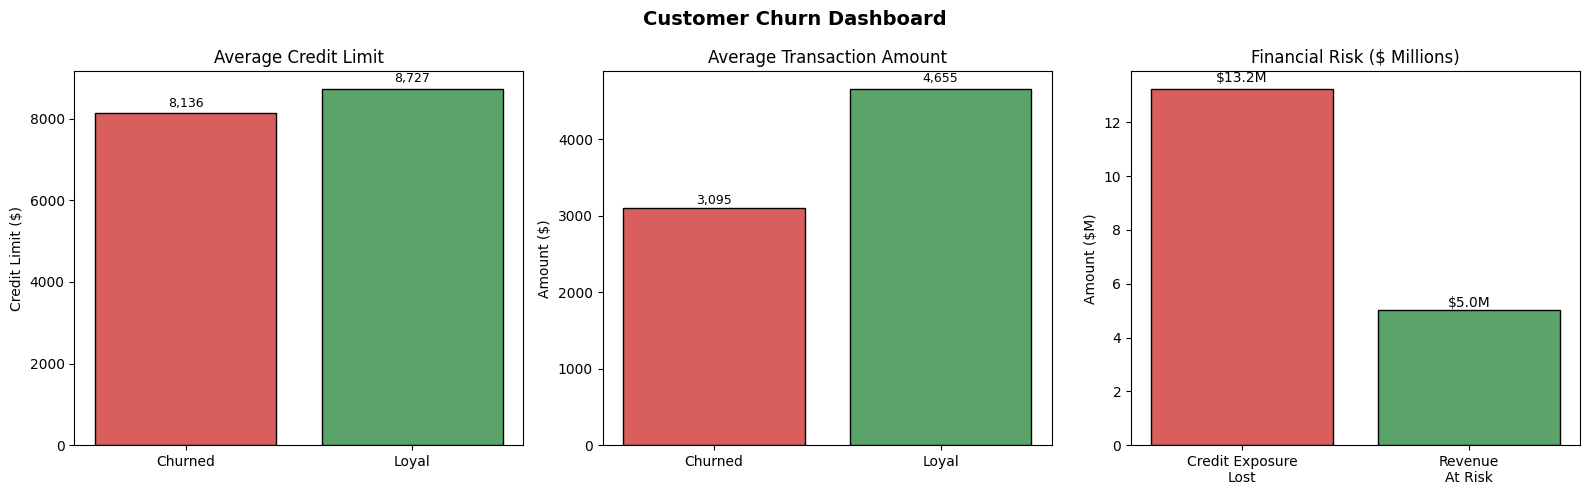


Observations
- Churned customers have lower transaction activity.
- Inactive customers seem more likely to churn.
- Churn causes a noticeable business impact.

Plot saved successfully


In [28]:
# Separate churned and loyal customers
churned = df[df["Churn"] == 1]
loyal = df[df["Churn"] == 0]

# Basic stats
avg_credit_limit_churned = churned["Credit_Limit"].mean()
avg_credit_limit_loyal = loyal["Credit_Limit"].mean()

total_credit_exposure = churned["Credit_Limit"].sum()

avg_trans_churned = churned["Total_Trans_Amt"].mean()
avg_trans_loyal = loyal["Total_Trans_Amt"].mean()

total_revenue_at_risk = churned["Total_Trans_Amt"].sum()

avg_inactive_churned = churned["Months_Inactive_12_mon"].mean()
avg_contacts_churned = churned["Contacts_Count_12_mon"].mean()
avg_revolving_churned = churned["Total_Revolving_Bal"].mean()

print("Customer Churn Analysis")
print("=" * 40)

print("\nCustomer Distribution")
print("Total Customers :", len(df))
print("Churned Customers :", len(churned), "(", round(df["Churn"].mean() * 100, 2), "%)")
print("Loyal Customers :", len(loyal), "(", round((1 - df["Churn"].mean()) * 100, 2), "%)")

print("\nCredit Exposure")
print("Average Credit Limit (Churned):", round(avg_credit_limit_churned, 2))
print("Average Credit Limit (Loyal):", round(avg_credit_limit_loyal, 2))
print("Total Credit Exposure Lost:", round(total_credit_exposure, 2))

print("\nTransaction Revenue")
print("Average Transaction Amount (Churned):", round(avg_trans_churned, 2))
print("Average Transaction Amount (Loyal):", round(avg_trans_loyal, 2))
print("Total Revenue At Risk:", round(total_revenue_at_risk, 2))

print("\nBehavioral Indicators")
print("Average Months Inactive:", round(avg_inactive_churned, 2))
print("Average Contacts Per Year:", round(avg_contacts_churned, 2))
print("Average Revolving Balance:", round(avg_revolving_churned, 2))

print("=" * 40)

# Plot dashboard
plt.style.use("default")

colors = {
    "churn": "#d95f5f",
    "loyal": "#5aa469"
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Customer Churn Dashboard", fontsize=14, fontweight="bold")

def annotate_bars(ax):
    for bar in ax.patches:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + h * 0.02,
            f"{h:,.0f}",
            ha="center",
            fontsize=9
        )

# Plot 1: Credit Limit
axes[0].bar(
    ["Churned", "Loyal"],
    [avg_credit_limit_churned, avg_credit_limit_loyal],
    color=[colors["churn"], colors["loyal"]],
    edgecolor="black"
)
axes[0].set_title("Average Credit Limit")
axes[0].set_ylabel("Credit Limit ($)")
annotate_bars(axes[0])

# Plot 2: Transaction Amount
axes[1].bar(
    ["Churned", "Loyal"],
    [avg_trans_churned, avg_trans_loyal],
    color=[colors["churn"], colors["loyal"]],
    edgecolor="black"
)
axes[1].set_title("Average Transaction Amount")
axes[1].set_ylabel("Amount ($)")
annotate_bars(axes[1])

# Plot 3: Financial Risk
risk_labels = ["Credit Exposure\nLost", "Revenue\nAt Risk"]
risk_values = [total_credit_exposure / 1e6, total_revenue_at_risk / 1e6]

bars = axes[2].bar(
    risk_labels,
    risk_values,
    color=[colors["churn"], colors["loyal"]],
    edgecolor="black"
)
axes[2].set_title("Financial Risk ($ Millions)")
axes[2].set_ylabel("Amount ($M)")

for bar in bars:
    h = bar.get_height()
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        h + h * 0.02,
        f"${h:.1f}M",
        ha="center"
    )

plt.tight_layout()
plt.savefig("01_kpi_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nObservations")
print("- Churned customers have lower transaction activity.")
print("- Inactive customers seem more likely to churn.")
print("- Churn causes a noticeable business impact.")

print("\nPlot saved successfully")

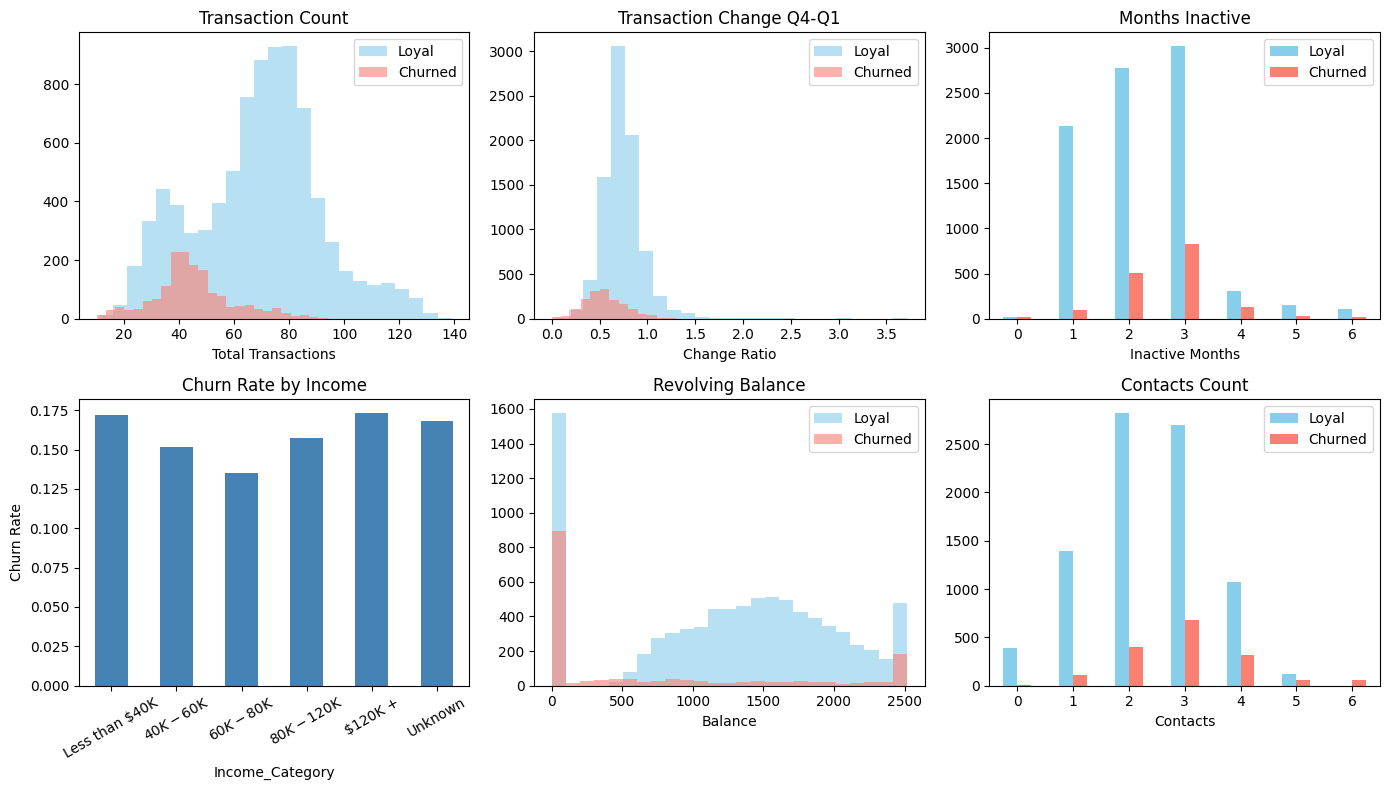

Behavioral EDA saved successfully


In [29]:
fig, axes = plt.subplots(2, 3, figsize=(14,8))

plot_colors = ["skyblue", "salmon"]

# 1 Transaction Count

for val, color, label in zip([0,1], plot_colors, ["Loyal","Churned"]):

    axes[0,0].hist(
        df[df["Churn"]==val]["Total_Trans_Ct"],
        bins=25,
        alpha=0.6,
        color=color,
        label=label
    )

axes[0,0].set_title("Transaction Count")
axes[0,0].set_xlabel("Total Transactions")
axes[0,0].legend()


# 2 Transaction Count Change

for val, color, label in zip([0,1], plot_colors, ["Loyal","Churned"]):

    axes[0,1].hist(
        df[df["Churn"]==val]["Total_Ct_Chng_Q4_Q1"],
        bins=25,
        alpha=0.6,
        color=color,
        label=label
    )

axes[0,1].set_title("Transaction Change Q4-Q1")
axes[0,1].set_xlabel("Change Ratio")
axes[0,1].legend()


# 3 Months Inactive

inactive = df.groupby(
    ["Months_Inactive_12_mon","Churn"]
).size().unstack(fill_value=0)

inactive.plot(
    kind="bar",
    ax=axes[0,2],
    color=plot_colors
)

axes[0,2].set_title("Months Inactive")
axes[0,2].set_xlabel("Inactive Months")
axes[0,2].legend(["Loyal","Churned"])
axes[0,2].tick_params(
    axis="x",
    rotation=0
)


# 4 Income Category

income_order = [

    "Less than $40K",
    "$40K - $60K",
    "$60K - $80K",
    "$80K - $120K",
    "$120K +",
    "Unknown"

]

income = (

    df.groupby("Income_Category")["Churn"]
    .mean()
    .reindex(income_order)

)

income.plot(

    kind="bar",
    ax=axes[1,0],
    color="steelblue"

)

axes[1,0].set_title("Churn Rate by Income")
axes[1,0].set_ylabel("Churn Rate")
axes[1,0].tick_params(
    axis="x",
    rotation=30
)


# 5 Revolving Balance

for val, color, label in zip([0,1], plot_colors, ["Loyal","Churned"]):

    axes[1,1].hist(
        df[df["Churn"]==val]["Total_Revolving_Bal"],
        bins=25,
        alpha=0.6,
        color=color,
        label=label
    )

axes[1,1].set_title("Revolving Balance")
axes[1,1].set_xlabel("Balance")
axes[1,1].legend()


# 6 Contacts Count

contacts = df.groupby(
    ["Contacts_Count_12_mon","Churn"]
).size().unstack(fill_value=0)

contacts.plot(
    kind="bar",
    ax=axes[1,2],
    color=plot_colors
)

axes[1,2].set_title("Contacts Count")
axes[1,2].set_xlabel("Contacts")
axes[1,2].legend(["Loyal","Churned"])

axes[1,2].tick_params(
    axis="x",
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "02_behavioral_eda.png",
    dpi=120
)

plt.show()

print("Behavioral EDA saved successfully")

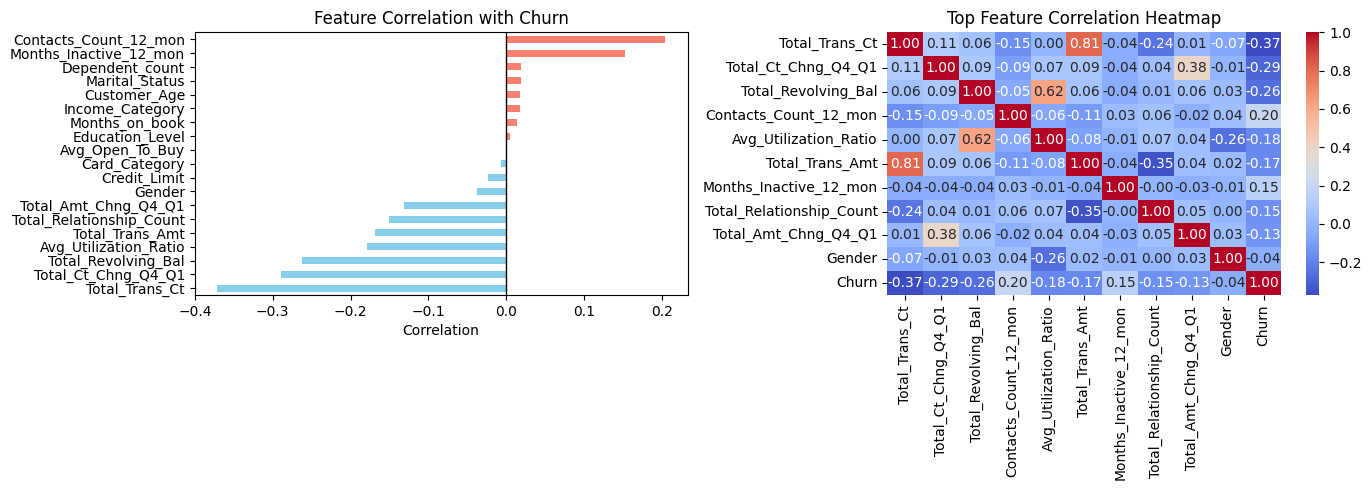

Correlation analysis saved successfully


In [30]:
# Convert categorical columns to numerical

df_corr = df.copy()

for col in df_corr.select_dtypes(include="object").columns:

    df_corr[col] = LabelEncoder().fit_transform(
        df_corr[col].astype(str)
    )


# Correlation with churn

target_corr = (

    df_corr.corr()["Churn"]
    .drop("Churn")
    .sort_values()

)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)


# Plot 1 Correlation Bar Plot

colors = [
    "salmon" if x > 0 else "skyblue"
    for x in target_corr
]

target_corr.plot(
    kind="barh",
    ax=axes[0],
    color=colors
)

axes[0].set_title(
    "Feature Correlation with Churn"
)

axes[0].set_xlabel(
    "Correlation"
)

axes[0].axvline(
    0,
    color="black",
    linewidth=1
)



# Plot 2 Heatmap

top_features = (

    abs(target_corr)
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()

)

top_features.append("Churn")

corr_matrix = df_corr[
    top_features
].corr()


sns.heatmap(

    corr_matrix,

    annot=True,

    cmap="coolwarm",

    fmt=".2f",

    ax=axes[1]

)

axes[1].set_title(
    "Top Feature Correlation Heatmap"
)


plt.tight_layout()

plt.savefig(
    "03_correlation_analysis.png",
    dpi=120
)

plt.show()

print(
    "Correlation analysis saved successfully"
)

In [5]:
X = df.drop(columns=["Churn"])
y = df["Churn"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

# Checking churn percentage
print("\nChurn % in Training Data :", round(y_train.mean()*100,2), "%")
print("Churn % in Testing Data  :", round(y_test.mean()*100,2), "%")
print("\nNext step: preprocessing and feature engineering on train data only")

Training Data Shape : (8101, 19)
Testing Data Shape  : (2026, 19)

Churn % in Training Data : 16.07 %
Churn % in Testing Data  : 16.04 %

Next step: preprocessing and feature engineering on train data only


In [31]:
# Feature Engineering

def engineer_features(X):
    X = X.copy()

    X["Utilization_Velocity"] = (
        X["Avg_Utilization_Ratio"] *
        X["Total_Ct_Chng_Q4_Q1"]
    )

    X["Inactivity_Weight"] = (
        X["Months_Inactive_12_mon"] *
        X["Contacts_Count_12_mon"]
    )

    X["Transaction_Trend"] = (
        X["Total_Ct_Chng_Q4_Q1"] *
        X["Total_Amt_Chng_Q4_Q1"]
    )

    X["Avg_Transaction_Value"] = (
        X["Total_Trans_Amt"] /
        (X["Total_Trans_Ct"] + 1)
    )

    X["Credit_Usage_Rate"] = (
        X["Total_Revolving_Bal"] /
        (X["Credit_Limit"] + 1)
    )

    X["Relationship_Density"] = (
        X["Total_Relationship_Count"] /
        (X["Months_on_book"] + 1)
    )

    X["Complaint_Risk"] = (
        X["Contacts_Count_12_mon"] /
        (X["Total_Relationship_Count"] + 1)
    )

    return X


# Apply feature engineering
X_train = engineer_features(X_train)
X_test = engineer_features(X_test)

new_features = [
    "Utilization_Velocity",
    "Inactivity_Weight",
    "Transaction_Trend",
    "Avg_Transaction_Value",
    "Credit_Usage_Rate",
    "Relationship_Density",
    "Complaint_Risk"
]

print("Features before:", X.shape[1])
print("Features after :", X_train.shape[1])

print("\nNew Features Added:")
for feature in new_features:
    print("-", feature)

Features before: 19
Features after : 26

New Features Added:
- Utilization_Velocity
- Inactivity_Weight
- Transaction_Trend
- Avg_Transaction_Value
- Credit_Usage_Rate
- Relationship_Density
- Complaint_Risk


In [32]:
# Preprocessing

cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical Columns:", cat_cols)
print("Number of Numeric Features:", len(num_cols))


# Encoding categorical variables

encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    X_train[col] = le.fit_transform(
        X_train[col].astype(str)
    )

    X_test[col] = X_test[col].astype(str).apply(
        lambda x: le.transform([x])[0]
        if x in le.classes_
        else -1
    )

    encoders[col] = le

print("\nEncoding completed")


# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

print("\nFinal Shape:", X_train.shape)

Categorical Columns: []
Number of Numeric Features: 26

Encoding completed
Scaling completed

Final Shape: (8101, 26)


In [33]:
# Create validation set from training data

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

# Scaled version for Logistic Regression

X_train_final_scaled = scaler.transform(X_train_final)
X_val_scaled = scaler.transform(X_val)

In [34]:
# Logistic Regression Model

lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    C=1,
    random_state=42
)

# Train model on training split
lr.fit(
    X_train_final_scaled,
    y_train_final
)

# Predictions on untouched test set

lr_pred = lr.predict(
    X_test_scaled
)

lr_prob = lr.predict_proba(
    X_test_scaled
)[:,1]


# Evaluation

print("Logistic Regression Results\n")

print(
    "ROC AUC :",
    round(
        roc_auc_score(
            y_test,
            lr_prob
        ),
        4
    )
)

print(
    "PR AUC :",
    round(
        average_precision_score(
            y_test,
            lr_prob
        ),
        4
    )
)

print(
    "F1 Score :",
    round(
        f1_score(
            y_test,
            lr_pred
        ),
        4
    )
)

print(
    "Recall :",
    round(
        recall_score(
            y_test,
            lr_pred
        ),
        4
    )
)

print(
    "Precision :",
    round(
        precision_score(
            y_test,
            lr_pred
        ),
        4
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        lr_pred,
        target_names=[
            "Loyal",
            "Churned"
        ]
    )
)

Logistic Regression Results

ROC AUC : 0.9322
PR AUC : 0.7577
F1 Score : 0.6658
Recall : 0.8308
Precision : 0.5556

Classification Report:

              precision    recall  f1-score   support

       Loyal       0.96      0.87      0.92      1701
     Churned       0.56      0.83      0.67       325

    accuracy                           0.87      2026
   macro avg       0.76      0.85      0.79      2026
weighted avg       0.90      0.87      0.88      2026



In [35]:
# Handling class imbalance

n_neg = (y_train_final == 0).sum()
n_pos = (y_train_final == 1).sum()

spw = n_neg / n_pos

print("Loyal Customers :", n_neg)
print("Churn Customers :", n_pos)
print("scale_pos_weight :", round(spw,2))


# XGBoost Model

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric="aucpr",
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)


# Training model

xgb_model.fit(
    X_train_final,
    y_train_final,
    eval_set=[
        (X_val, y_val)
    ],
    verbose=False
)


# Predictions

xgb_pred = xgb_model.predict(
    X_test
)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:,1]


# Evaluation

print("\nXGBoost Results\n")

print(
    "ROC AUC :",
    round(
        roc_auc_score(
            y_test,
            xgb_prob
        ),
        4
    )
)

print(
    "PR AUC :",
    round(
        average_precision_score(
            y_test,
            xgb_prob
        ),
        4
    )
)

print(
    "F1 Score :",
    round(
        f1_score(
            y_test,
            xgb_pred
        ),
        4
    )
)

print(
    "Recall :",
    round(
        recall_score(
            y_test,
            xgb_pred
        ),
        4
    )
)

print(
    "Precision :",
    round(
        precision_score(
            y_test,
            xgb_pred
        ),
        4
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=[
            "Loyal",
            "Churned"
        ]
    )
)

Loyal Customers : 5439
Churn Customers : 1041
scale_pos_weight : 5.22

XGBoost Results

ROC AUC : 0.9918
PR AUC : 0.9645
F1 Score : 0.9006
Recall : 0.8923
Precision : 0.9091

Classification Report:

              precision    recall  f1-score   support

       Loyal       0.98      0.98      0.98      1701
     Churned       0.91      0.89      0.90       325

    accuracy                           0.97      2026
   macro avg       0.94      0.94      0.94      2026
weighted avg       0.97      0.97      0.97      2026



In [36]:
# LightGBM Model

lgbm_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=40,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    metric="average_precision",
    random_state=42,
    n_jobs=-1,
    verbose=-1
)


# Training

lgbm_model.fit(
    X_train_final,
    y_train_final,

    eval_set=[
        (X_val, y_val)
    ],

    callbacks=[
        lgb.early_stopping(
            30,
            verbose=False
        )
    ]
)


# Predictions

lgbm_pred = lgbm_model.predict(
    X_test
)

lgbm_prob = lgbm_model.predict_proba(
    X_test
)[:,1]


# Evaluation

print("\nLightGBM Results\n")

print(
    "ROC AUC :",
    round(
        roc_auc_score(
            y_test,
            lgbm_prob
        ),
        4
    )
)

print(
    "PR AUC :",
    round(
        average_precision_score(
            y_test,
            lgbm_prob
        ),
        4
    )
)

print(
    "F1 Score :",
    round(
        f1_score(
            y_test,
            lgbm_pred
        ),
        4
    )
)

print(
    "Recall :",
    round(
        recall_score(
            y_test,
            lgbm_pred
        ),
        4
    )
)

print(
    "Precision :",
    round(
        precision_score(
            y_test,
            lgbm_pred
        ),
        4
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        lgbm_pred,
        target_names=[
            "Loyal",
            "Churned"
        ]
    )
)


LightGBM Results

ROC AUC : 0.9909
PR AUC : 0.959
F1 Score : 0.8731
Recall : 0.8892
Precision : 0.8576

Classification Report:

              precision    recall  f1-score   support

       Loyal       0.98      0.97      0.98      1701
     Churned       0.86      0.89      0.87       325

    accuracy                           0.96      2026
   macro avg       0.92      0.93      0.92      2026
weighted avg       0.96      0.96      0.96      2026




Model Comparison

              Model  ROC_AUC  PR_AUC     F1  Recall  Precision
Logistic Regression   0.9322  0.7577 0.6658  0.8308     0.5556
            XGBoost   0.9918  0.9645 0.9006  0.8923     0.9091
           LightGBM   0.9909  0.9590 0.8731  0.8892     0.8576


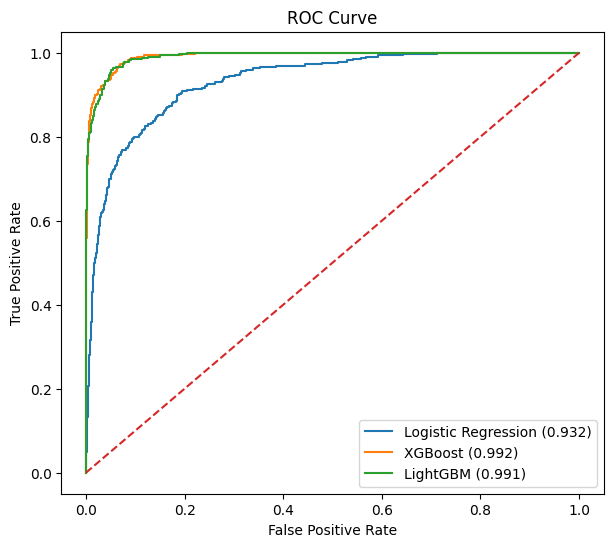

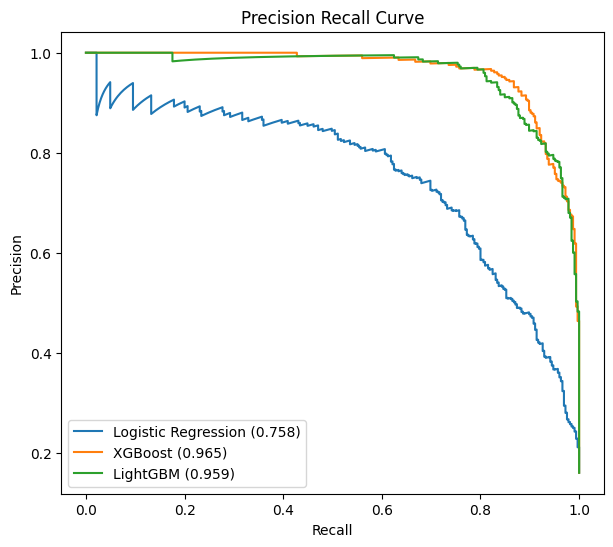

In [37]:
# Comparing Models

model_results = {

    "Logistic Regression": {
        "prob": lr_prob,
        "pred": lr_pred
    },

    "XGBoost": {
        "prob": xgb_prob,
        "pred": xgb_pred
    },

    "LightGBM": {
        "prob": lgbm_prob,
        "pred": lgbm_pred
    }

}


# Creating Summary Table

summary = []

for name, result in model_results.items():

    summary.append({

        "Model": name,

        "ROC_AUC": round(
            roc_auc_score(
                y_test,
                result["prob"]
            ),
            4
        ),

        "PR_AUC": round(
            average_precision_score(
                y_test,
                result["prob"]
            ),
            4
        ),

        "F1": round(
            f1_score(
                y_test,
                result["pred"]
            ),
            4
        ),

        "Recall": round(
            recall_score(
                y_test,
                result["pred"]
            ),
            4
        ),

        "Precision": round(
            precision_score(
                y_test,
                result["pred"]
            ),
            4
        )

    })


summary_df = pd.DataFrame(
    summary
)

print("\nModel Comparison\n")

print(
    summary_df.to_string(
        index=False
    )
)



# ROC Curve

plt.figure(figsize=(7,6))

for name, result in model_results.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        result["prob"]
    )

    auc_score = roc_auc_score(
        y_test,
        result["prob"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} ({auc_score:.3f})"
    )


plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.show()



# Precision Recall Curve

plt.figure(figsize=(7,6))

for name, result in model_results.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        result["prob"]
    )

    pr_score = average_precision_score(
        y_test,
        result["prob"]
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} ({pr_score:.3f})"
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision Recall Curve"
)

plt.legend()

plt.show()

Best model: XGBoost
  Strategy    Thr    Rec   Prec     F1   TP  FN   FP
0  Default  0.500  0.892  0.909  0.901  290  35   29
1       F1  0.680  0.868  0.943  0.904  282  43   17
2   Recall  0.009  0.994  0.500  0.665  323   2  323


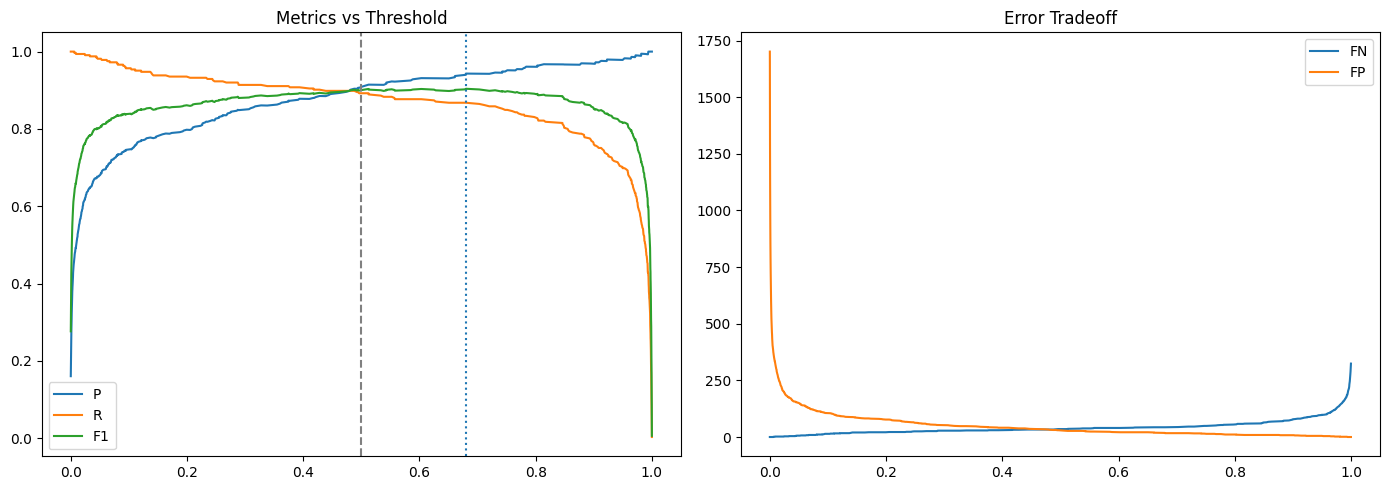

Saved plot


In [38]:
# Threshold tuning using best ROC-AUC model

best_model_idx = summary_df["ROC_AUC"].idxmax()
best_model = summary_df.loc[best_model_idx, "Model"]
best_probs = model_results[best_model]["prob"]

print("Best model:", best_model)

precision, recall, thresholds = precision_recall_curve(y_test, best_probs)
f1 = (2 * precision * recall) / (precision + recall + 1e-10)

best_f1_t = thresholds[np.argmax(f1[:-1])]
valid = np.where(precision[:-1] >= 0.5)[0]

recall_t = thresholds[valid[np.argmax(recall[:-1][valid])]] if len(valid) else best_f1_t


# evaluation at different thresholds
cases = [("Default",0.5),("F1",best_f1_t),("Recall",recall_t)]

rows = []
for n,t in cases:
    p = (best_probs >= t).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_test,p).ravel()

    rows.append([
        n,round(t,3),
        round(recall_score(y_test,p),3),
        round(precision_score(y_test,p,zero_division=0),3),
        round(f1_score(y_test,p),3),
        tp,fn,fp
    ])

threshold_summary_df = pd.DataFrame(rows,columns=["Strategy","Thr","Rec","Prec","F1","TP","FN","FP"])
print(threshold_summary_df)


# plots
fig,ax = plt.subplots(1,2,figsize=(14,5))

ax[0].plot(thresholds,precision[:-1],label="P")
ax[0].plot(thresholds,recall[:-1],label="R")
ax[0].plot(thresholds,f1[:-1],label="F1")
ax[0].axvline(0.5,ls="--",c="gray")
ax[0].axvline(best_f1_t,ls=":")
ax[0].set_title("Metrics vs Threshold")
ax[0].legend()

fn = [((best_probs<t)&(y_test==1)).sum() for t in thresholds]
fp = [((best_probs>=t)&(y_test==0)).sum() for t in thresholds]

ax[1].plot(thresholds,fn,label="FN")
ax[1].plot(thresholds,fp,label="FP")
ax[1].set_title("Error Tradeoff")
ax[1].legend()

plt.tight_layout()
plt.savefig("05_threshold.png",dpi=150,bbox_inches="tight")
plt.show()

print("Saved plot")

SHAP values generated
Shape of SHAP matrix: (2026, 26)


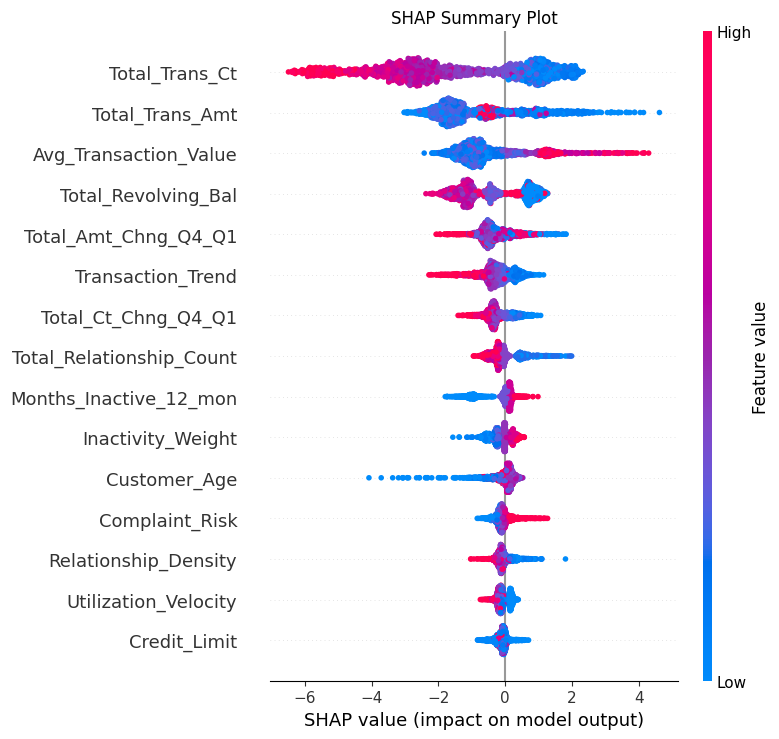

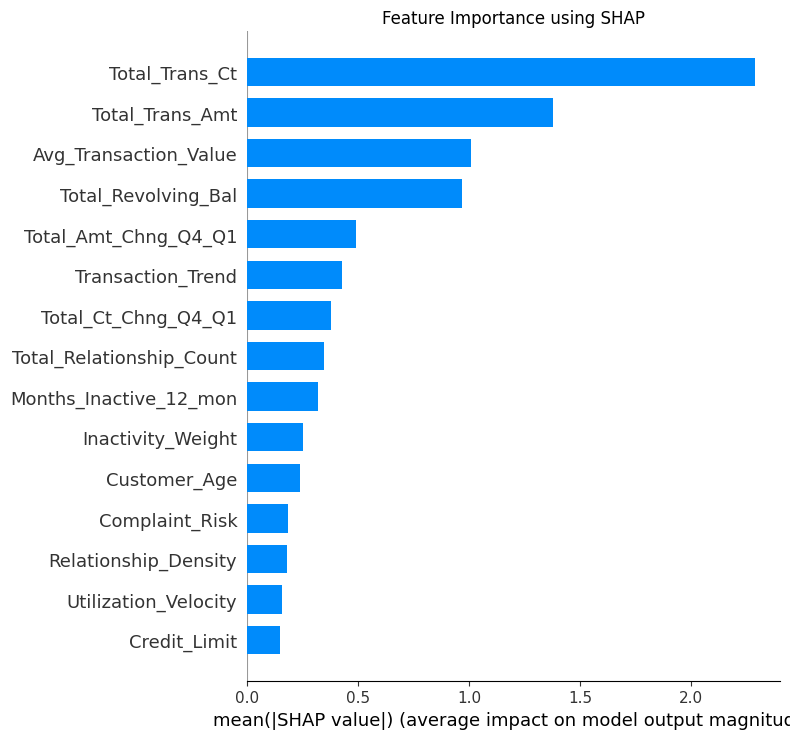

Plots saved successfully


In [39]:
# SHAP analysis for the best model

if best_model == "XGBoost":
    model = xgb_model
else:
    model = lgbm_model

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# For LightGBM binary classification
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("SHAP values generated")
print("Shape of SHAP matrix:", shap_values.shape)


# Summary plot
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
    max_display=15,
    show=False
)

plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.savefig("06_shap_summary.png", dpi=150)
plt.show()


# Feature importance plot
plt.figure(figsize=(8, 6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title("Feature Importance using SHAP")
plt.tight_layout()
plt.savefig("07_shap_feature_importance.png", dpi=150)
plt.show()

print("Plots saved successfully")

High Risk Customer
Predicted churn probability: 99.99 %
Actual label: Churned

Safe Customer
Predicted churn probability: 0.0 %
Actual label: Not Churned


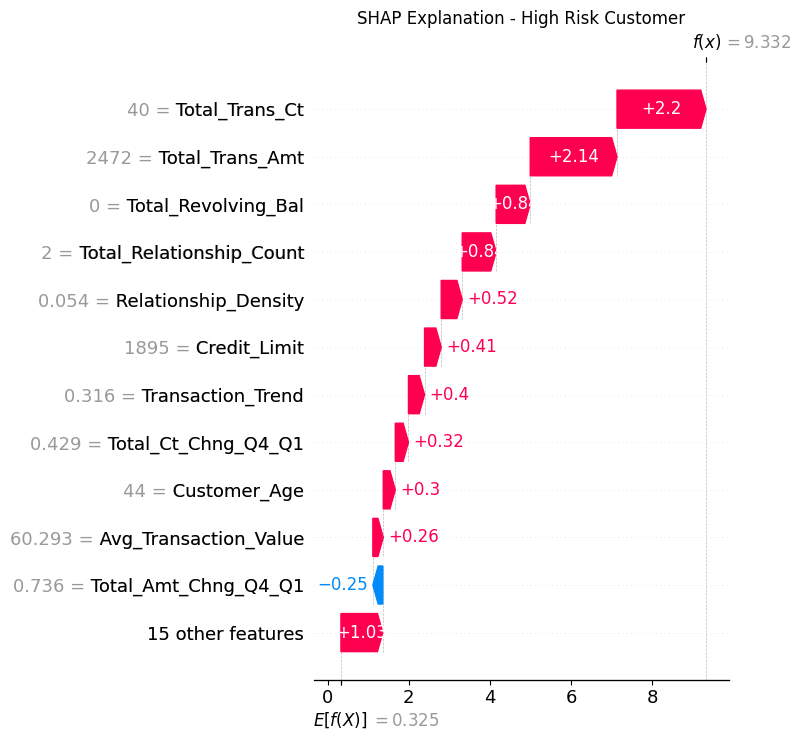

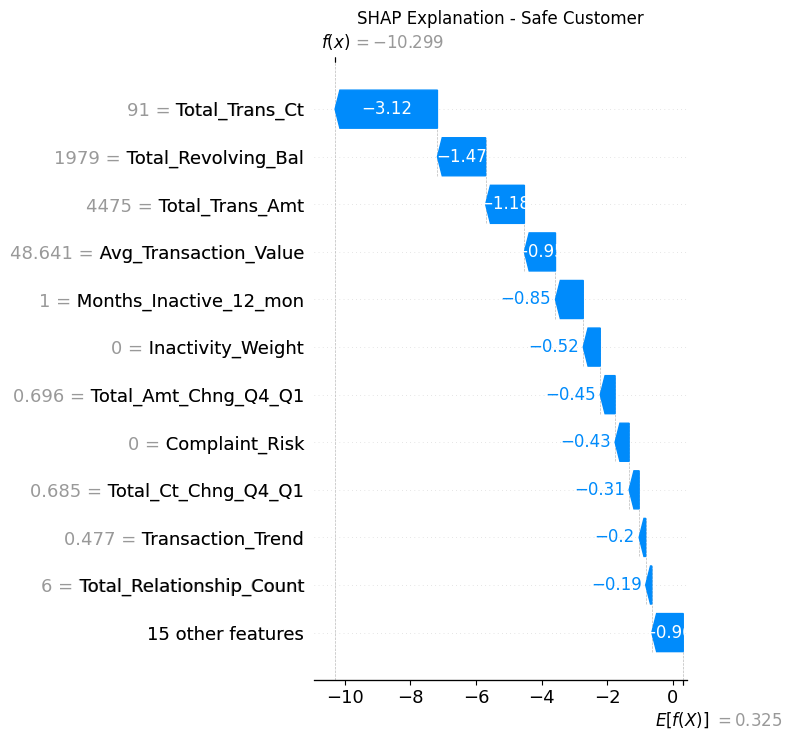

Waterfall plots saved


In [40]:
# SHAP explanation for individual customers

# Customer with highest churn probability
high_risk_idx = np.argmax(best_probs)

# Customer with lowest churn probability
safe_idx = np.argmin(best_probs)

print("High Risk Customer")
print("Predicted churn probability:",
      round(best_probs[high_risk_idx] * 100, 2), "%")

print("Actual label:",
      "Churned" if y_test.iloc[high_risk_idx] == 1 else "Not Churned")

print("\nSafe Customer")
print("Predicted churn probability:",
      round(best_probs[safe_idx] * 100, 2), "%")

print("Actual label:",
      "Not Churned" if y_test.iloc[safe_idx] == 0 else "Churned")


# High-risk customer explanation
plt.figure(figsize=(10, 6))

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_idx].values,
        feature_names=X_test.columns
    ),
    max_display=12,
    show=False
)

plt.title("SHAP Explanation - High Risk Customer")
plt.tight_layout()
plt.savefig("08_high_risk_customer.png", dpi=150)
plt.show()


# Safe customer explanation
plt.figure(figsize=(10, 6))

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[safe_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[safe_idx].values,
        feature_names=X_test.columns
    ),
    max_display=12,
    show=False
)

plt.title("SHAP Explanation - Safe Customer")
plt.tight_layout()
plt.savefig("09_safe_customer.png", dpi=150)
plt.show()

print("Waterfall plots saved")

<Figure size 500x400 with 0 Axes>

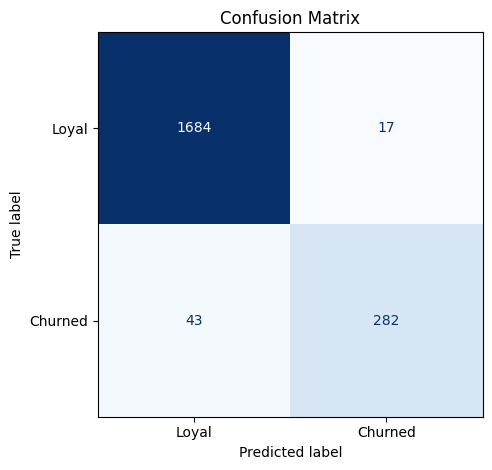

Files saved successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Final Results
----------------------------------------
Best Model : XGBoost
Optimal Threshold : 0.68

Confusion Matrix Values
TP : 282
TN : 1684
FP : 17
FN : 43

Recall : 0.868
Precision : 0.943

Total Features : 26
Total Records : 10127


In [41]:
# Confusion Matrix

preds = (best_probs >= best_f1_t).astype(int)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5,4))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Loyal", "Churned"]
).plot(cmap="Blues", colorbar=False)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("10_confusion_matrix.png", dpi=150)
plt.show()


# Save model and required files

joblib.dump(model, "churn_model.pkl")
joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")
joblib.dump(encoders, "encoders.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(best_f1_t, "optimal_threshold.pkl")

print("Files saved successfully")


# Download files

from google.colab import files

files_to_download = [
    "churn_model.pkl",
    "feature_columns.pkl",
    "encoders.pkl",
    "scaler.pkl",
    "optimal_threshold.pkl"
]

for file in files_to_download:
    files.download(file)


# Final results

tn, fp, fn, tp = cm.ravel()

print("\nFinal Results")
print("-" * 40)

print("Best Model :", best_model)
print("Optimal Threshold :", round(best_f1_t, 3))

print("\nConfusion Matrix Values")
print("TP :", tp)
print("TN :", tn)
print("FP :", fp)
print("FN :", fn)

print("\nRecall :", round(tp / (tp + fn), 3))
print("Precision :", round(tp / (tp + fp), 3))

print("\nTotal Features :", X_train.shape[1])
print("Total Records :", len(df))